In [ ]:
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error

# Load the merged dataset
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/final_7features_state_IX.csv')

state_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9}
df['state'] = df['state'].map(state_map)

train_groups = [(25, 6), (25, 7), (25, 8), (25, 5), (25, 3), (25, 4), (35, 1)]
val_groups   = [(25, 2), (45, 2)]                 # validation cell(s)
test_groups  = [(25, 1), (35, 2), (45, 1)]         # final test cell(s)


In [18]:
def mask_from_groups(df, groups):
    groups = set(groups)
    return df.apply(lambda r: (r["T_C"], r["cell"]) in groups, axis=1)

train_mask = mask_from_groups(df, train_groups)
val_mask   = mask_from_groups(df, val_groups)
test_mask  = mask_from_groups(df, test_groups)

train_df = df[train_mask].copy()
val_df   = df[val_mask].copy()
test_df  = df[test_mask].copy()

print("Train:", train_df.shape, "Groups:", sorted(set(zip(train_df.T_C, train_df.cell))))
print("Val  :", val_df.shape,   "Groups:", sorted(set(zip(val_df.T_C, val_df.cell))))
print("Test :", test_df.shape,  "Groups:", sorted(set(zip(test_df.T_C, test_df.cell))))


Train: (1279, 13) Groups: [(25, 3), (25, 4), (25, 5), (25, 6), (25, 7), (25, 8), (35, 1)]
Val  : (491, 13) Groups: [(25, 2), (45, 2)]
Test : (966, 13) Groups: [(25, 1), (35, 2), (45, 1)]


In [24]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

features = [
    "R_s_rel",
    "R_ct_rel",
    "R_sei_rel",
    "Zmag_0.1Hz_rel",
    "C_dl_log",
    "tail_slope","Zmag_1000Hz_rel",
    "T_C"
]

def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred)))
    }

X_train, y_train = train_df[features], train_df["SOH"]
X_val,   y_val   = val_df[features],   val_df["SOH"]
X_test,  y_test  = test_df[features],  test_df["SOH"]

print("NaNs train:", X_train.isna().sum().sum(), "val:", X_val.isna().sum().sum(), "test:", X_test.isna().sum().sum())


NaNs train: 0 val: 0 test: 0


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

gbr = HistGradientBoostingRegressor(
    learning_rate=0.01,
    max_depth=3,
    max_iter=1000,   
    random_state=42
)

gbr.fit(X_train, y_train)
print("Gradient Boosting performance")
print("Train:", metrics(y_train, gbr.predict(X_train)))
print("Val  :", metrics(y_val,   gbr.predict(X_val)))
print("Test :", metrics(y_test,  gbr.predict(X_test)))



Gradient Boosting performance
Train: {'R2': 0.9923860716734577, 'MAE': 0.011692321874710598, 'RMSE': 0.017213703386062103}
Val  : {'R2': 0.4107939068678904, 'MAE': 0.051319310890330976, 'RMSE': 0.0548586289227954}
Test : {'R2': 0.8593658916551057, 'MAE': 0.04932362990573167, 'RMSE': 0.06809034841502613}


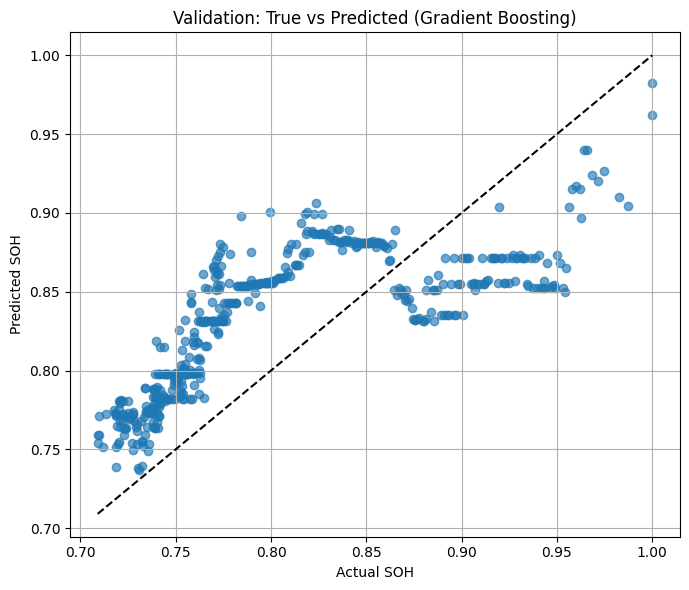

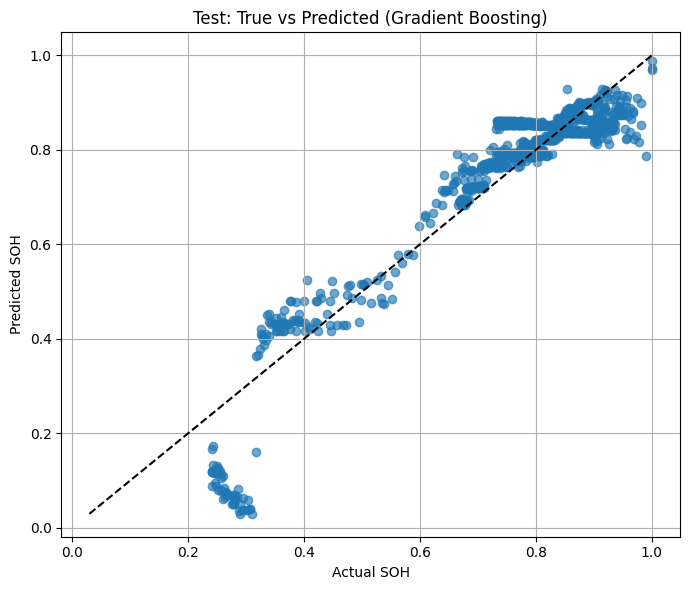

In [30]:
import matplotlib.pyplot as plt

def true_vs_pred_plot(y_true, y_pred, title):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(7,6))
    plt.scatter(y_true, y_pred, alpha=0.65)
    plt.plot([lo, hi], [lo, hi], "k--")
    plt.xlabel("Actual SOH")
    plt.ylabel("Predicted SOH")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

true_vs_pred_plot(y_val,  gbr.predict(X_val),  "Validation: True vs Predicted (Gradient Boosting)")
true_vs_pred_plot(y_test, gbr.predict(X_test), "Test: True vs Predicted (Gradient Boosting)")


In [27]:
from sklearn.metrics import mean_squared_error

grid = []
best = None
best_rmse = np.inf

for max_depth in [2, 3, 4, 5, 6]:
    for lr in [0.01, 0.03, 0.05, 0.1]:
        for max_iter in [500, 1000, 2000, 4000]:
            model = HistGradientBoostingRegressor(
                learning_rate=lr,
                max_depth=max_depth,
                max_iter=max_iter,
                random_state=42
            )
            model.fit(X_train, y_train)
            val_pred = model.predict(X_val)
            rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))

            grid.append({"max_depth": max_depth, "learning_rate": lr, "max_iter": max_iter, "val_rmse": rmse})

            if rmse < best_rmse:
                best_rmse = rmse
                best = model
                best_params = {"max_depth": max_depth, "learning_rate": lr, "max_iter": max_iter}

grid_df = pd.DataFrame(grid).sort_values("val_rmse")
print("Best params:", best_params, "Best Val RMSE:", best_rmse)
grid_df.head(10)


Best params: {'max_depth': 3, 'learning_rate': 0.01, 'max_iter': 1000} Best Val RMSE: 0.0548586289227954


,max_depth,learning_rate,max_iter,val_rmse
17,3,0.01,1000,0.054859
16,3,0.01,500,0.056807
18,3,0.01,2000,0.057904
1,2,0.01,1000,0.058525
24,3,0.05,500,0.058900
8,2,0.05,500,0.059278
20,3,0.03,500,0.060116
19,3,0.01,4000,0.060200
33,4,0.01,1000,0.060216
34,4,0.01,2000,0.060343


In [28]:
print("BEST Gradient Boosting performance")
print("Train:", metrics(y_train, best.predict(X_train)))
print("Val  :", metrics(y_val,   best.predict(X_val)))
print("Test :", metrics(y_test,  best.predict(X_test)))


BEST Gradient Boosting performance
Train: {'R2': 0.9923860716734577, 'MAE': 0.011692321874710598, 'RMSE': 0.017213703386062103}
Val  : {'R2': 0.4107939068678904, 'MAE': 0.051319310890330976, 'RMSE': 0.0548586289227954}
Test : {'R2': 0.8593658916551057, 'MAE': 0.04932362990573167, 'RMSE': 0.06809034841502613}


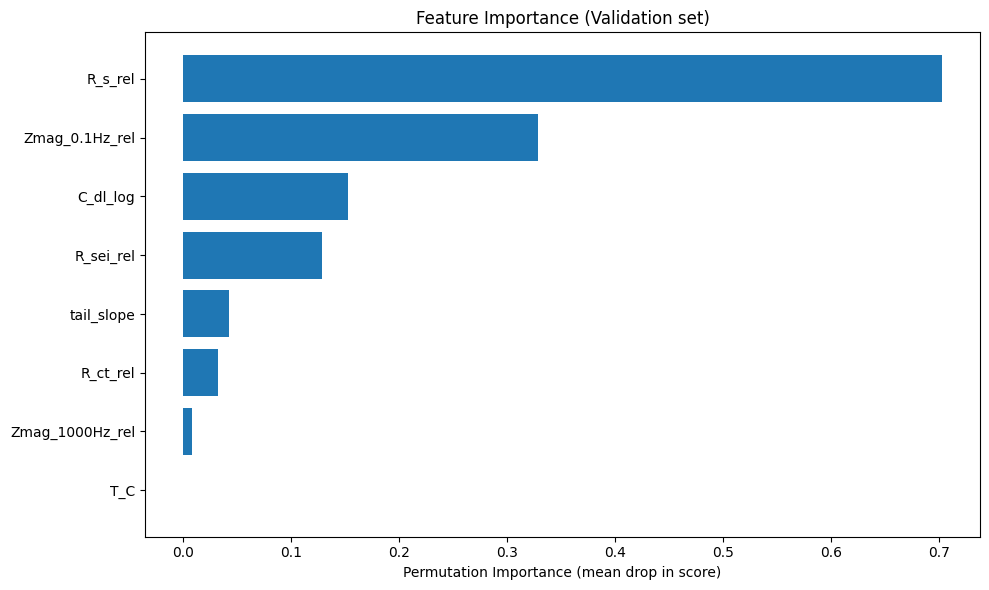

In [31]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best, X_val, y_val, n_repeats=30, random_state=42, n_jobs=-1)
imp = pd.DataFrame({"feature": features, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std})
imp = imp.sort_values("importance_mean", ascending=False)
imp

plt.figure(figsize=(10,6))
plt.barh(imp["feature"], imp["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (mean drop in score)")
plt.title("Feature Importance (Validation set)")
plt.tight_layout()
plt.show()


lightgbm

In [ ]:
import numpy as np

X_train_c = X_train.replace([np.inf, -np.inf], np.nan)
X_val_c   = X_val.replace([np.inf, -np.inf], np.nan)
X_test_c  = X_test.replace([np.inf, -np.inf], np.nan)


In [42]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=15,
    max_depth=-1,          # -1 = no limit
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1.0,
    min_child_samples=50,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(
    X_train_c, y_train,
    eval_set=[(X_val_c, y_val)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
)

print("Train:", metrics(y_train, lgbm.predict(X_train_c)))
print("Val  :", metrics(y_val,   lgbm.predict(X_val_c)))
print("Test :", metrics(y_test,  lgbm.predict(X_test_c)))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1788
[LightGBM] [Info] Number of data points in the train set: 1279, number of used features: 8
[LightGBM] [Info] Start training from score 0.702270
Train: {'R2': 0.9910174684960048, 'MAE': 0.012683037253204063, 'RMSE': 0.018696886757977024}
Val  : {'R2': 0.5487561294047145, 'MAE': 0.04187325718937395, 'RMSE': 0.048008373477773765}
Test : {'R2': 0.8712214750376593, 'MAE': 0.04781203379846517, 'RMSE': 0.0651571301642427}


In [41]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

results = []
best_rmse = np.inf
best_lgbm = None
best_params = None

for num_leaves in [15, 31, 63, 127]:
    for lr in [0.01, 0.03, 0.05]:
        for min_child_samples in [10, 20, 50]:
            for subsample in [0.7, 0.85, 1.0]:
                for colsample in [0.7, 0.85, 1.0]:

                    lgbm = lgb.LGBMRegressor(
                        n_estimators=10000,
                        learning_rate=lr,
                        num_leaves=num_leaves,
                        min_child_samples=min_child_samples,
                        subsample=subsample,
                        colsample_bytree=colsample,
                        reg_lambda=1.0,
                        random_state=42,
                        n_jobs=-1
                    )

                    lgbm.fit(
                        X_train_c, y_train,
                        eval_set=[(X_val_c, y_val)],
                        eval_metric="rmse",
                        callbacks=[lgb.early_stopping(stopping_rounds=300, verbose=False)]
                    )

                    pred = lgbm.predict(X_val_c)
                    rmse = float(np.sqrt(mean_squared_error(y_val, pred)))

                    row = {
                        "num_leaves": num_leaves,
                        "learning_rate": lr,
                        "min_child_samples": min_child_samples,
                        "subsample": subsample,
                        "colsample_bytree": colsample,
                        "best_iteration": int(lgbm.best_iteration_),
                        "val_rmse": rmse
                    }
                    results.append(row)

                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_lgbm = lgbm
                        best_params = row

res_df = pd.DataFrame(results).sort_values("val_rmse")
print("Best params:", best_params)
print("Best Val RMSE:", best_rmse)
res_df.head(10)

print("Train:", metrics(y_train, best_lgbm.predict(X_train_c)))
print("Val  :", metrics(y_val,   best_lgbm.predict(X_val_c)))
print("Test :", metrics(y_test,  best_lgbm.predict(X_test_c)))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000287 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1788
[LightGBM] [Info] Number of data points in the train set: 1279, number of used features: 8
[LightGBM] [Info] Start training from score 0.702270
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000177 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1788
[LightGBM] [Info] Number of data points in the train set: 1279, number of used features: 8
[LightGBM] [Info] Start training from score 0.702270
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000225 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1788
[LightGBM] [Info] Number of data points in the train set: 1279, number of used features: 8
[LightGBM] [Info] Start training 

In [34]:
import xgboost as xgb
print(xgb.__version__)


2.1.4


In [ ]:
import numpy as np
from xgboost import XGBRegressor

X_train_c = X_train.replace([np.inf, -np.inf], np.nan)
X_val_c   = X_val.replace([np.inf, -np.inf], np.nan)
X_test_c  = X_test.replace([np.inf, -np.inf], np.nan)

xgb_model = XGBRegressor(
    n_estimators=8000,
    learning_rate=0.08,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=0.7,
    reg_lambda=0.5,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=300  
)

xgb_model.fit(
    X_train_c, y_train,
    eval_set=[(X_val_c, y_val)],
    verbose=False
)

print("Best iteration:", getattr(xgb_model, "best_iteration", None))
print("Train:", metrics(y_train, xgb_model.predict(X_train_c)))
print("Val  :", metrics(y_val,   xgb_model.predict(X_val_c)))
print("Test :", metrics(y_test,  xgb_model.predict(X_test_c)))


Best iteration: 37
Train: {'R2': 0.9653023815069247, 'MAE': 0.027426934977731326, 'RMSE': 0.0367468195653927}
Val  : {'R2': 0.5760545592431952, 'MAE': 0.041576578320141215, 'RMSE': 0.04653356428069558}
Test : {'R2': 0.9037660813362612, 'MAE': 0.04416528329517812, 'RMSE': 0.05632540327040279}


tuning 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

X_train_c = X_train.replace([np.inf, -np.inf], np.nan)
X_val_c   = X_val.replace([np.inf, -np.inf], np.nan)
X_test_c  = X_test.replace([np.inf, -np.inf], np.nan)

results = []
best_rmse = np.inf
best_model = None
best_row = None

grid = {
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 5, 10],
    "reg_lambda": [0.5, 1.0, 5.0],
}

for max_depth in grid["max_depth"]:
    for lr in grid["learning_rate"]:
        for subsample in grid["subsample"]:
            for colsample in grid["colsample_bytree"]:
                for min_child_weight in grid["min_child_weight"]:
                    for reg_lambda in grid["reg_lambda"]:

                        model = XGBRegressor(
                            n_estimators=20000,            
                            learning_rate=lr,
                            max_depth=max_depth,
                            subsample=subsample,
                            colsample_bytree=colsample,
                            min_child_weight=min_child_weight,
                            reg_lambda=reg_lambda,
                            random_state=42,
                            n_jobs=-1,
                            objective="reg:squarederror",
                            eval_metric="rmse",
                            early_stopping_rounds=300
                        )

                        model.fit(
                            X_train_c, y_train,
                            eval_set=[(X_val_c, y_val)],
                            verbose=False
                        )

                        val_pred = model.predict(X_val_c)
                        rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))

                        row = {
                            "max_depth": max_depth,
                            "learning_rate": lr,
                            "subsample": subsample,
                            "colsample_bytree": colsample,
                            "min_child_weight": min_child_weight,
                            "reg_lambda": reg_lambda,
                            "best_iteration": int(getattr(model, "best_iteration", -1)),
                            "val_rmse": rmse
                        }
                        results.append(row)

                        if rmse < best_rmse:
                            best_rmse = rmse
                            best_model = model
                            best_row = row

res_df = pd.DataFrame(results).sort_values("val_rmse")
print("Best params:", best_row)
print("Best Val RMSE:", best_rmse)
res_df.head(10)


Best params: {'max_depth': 3, 'learning_rate': 0.08, 'subsample': 1.0, 'colsample_bytree': 0.7, 'min_child_weight': 5, 'reg_lambda': 0.5, 'best_iteration': 37, 'val_rmse': 0.046264876788900906}
Best Val RMSE: 0.046264876788900906


,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda,best_iteration,val_rmse
303,3,0.08,1.0,0.70,10,0.5,37,0.046265
300,3,0.08,1.0,0.70,5,0.5,37,0.046265
226,3,0.05,1.0,0.85,1,1.0,52,0.046265
229,3,0.05,1.0,0.85,5,1.0,52,0.046265
232,3,0.05,1.0,0.85,10,1.0,52,0.046265
572,4,0.08,0.7,0.70,5,5.0,71,0.046306
891,5,0.08,0.7,0.70,1,0.5,40,0.046445
140,3,0.03,1.0,0.70,5,5.0,101,0.046496
297,3,0.08,1.0,0.70,1,0.5,37,0.046534
249,3,0.08,0.7,0.70,10,0.5,36,0.046570


In [37]:
print("Tuned XGB")
print("Train:", metrics(y_train, best_model.predict(X_train_c)))
print("Val  :", metrics(y_val,   best_model.predict(X_val_c)))
print("Test :", metrics(y_test,  best_model.predict(X_test_c)))


Tuned XGB
Train: {'R2': 0.9653032910972744, 'MAE': 0.02751869055611046, 'RMSE': 0.036746337907386115}
Val  : {'R2': 0.5809361960050985, 'MAE': 0.041230085883960946, 'RMSE': 0.046264876788900906}
Test : {'R2': 0.9042340334897957, 'MAE': 0.04403286916488089, 'RMSE': 0.05618829093919117}
